In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [14]:
meta = pd.read_parquet("../metadata_for_student.parquet")

print(meta.head())

                                                 raw_file   scan  charge
317151  EXPLO_NGL_YD1_240719_Expi_LysN_ECD_900kHz_4p6A...  14153       2
115695  EXPLO_NGL_YD1_240718_Expi_chymo_ECD_900kHz_4p6...  11032       3
256476  EXPLO_NGL_YD1_241126_Expi_GluC_ECD50ms_900kHz_...  16506       4
84283   EXPLO_NGL_YD1_240718_Expi_chymo_ECD_900kHz_4p6...  12573       5
121116  EXPLO_NGL_YD1_241126_Expi_GluC_ECD50ms_900kHz_...  14485       3


In [15]:

df = pd.read_parquet("../data_for_student.parquet")
print(df.shape)
print(df.dtypes)

df.head(3)

(379534, 5)
raw_file                str
scan                  int64
modified_sequence       str
matched_ions         object
intensity            object
dtype: object


,raw_file,scan,modified_sequence,matched_ions,intensity
0,EXPLO_NGL_YD1_240712_Expi_LysC_ECD50ms_900kHz_...,3732,EENRRPPSGDNAREKPPSSGVKK,"[C4, z4, z5, C9^2, z9^2, C11^2, z11^2, Z11^2, ...","[4693.457, 2065.6274, 3287.1636, 7479.8574, 24..."
1,EXPLO_NGL_YD1_240712_Expi_LysC_ECD50ms_900kHz_...,3849,VRNHYNEEM[UNIMOD:35]SNLRNK,"[C3, z3, C4, z4, Z4, C5, z5, Z5, C6, z6, Z6, C...","[27414.615, 30732.162, 51714.02, 41634.367, 14..."
2,EXPLO_NGL_YD1_240712_Expi_LysC_ECD50ms_900kHz_...,3890,EHQRILARRQTIEERK,"[C3, z3, Z3, C4, z4, Z4, C5, z5, Z5, C6, z6, C...","[18523.092, 17844.998, 4973.6216, 8429.15, 112..."


In [25]:
comb = df.merge(meta, 'outer',['scan'])

print(comb.where(comb['charge'].isna()).where(comb['scan'].isna() == False))

print(comb.head())

        raw_file_x  scan modified_sequence matched_ions intensity raw_file_y  \
0              NaN   NaN               NaN          NaN       NaN        NaN   
1              NaN   NaN               NaN          NaN       NaN        NaN   
2              NaN   NaN               NaN          NaN       NaN        NaN   
3              NaN   NaN               NaN          NaN       NaN        NaN   
4              NaN   NaN               NaN          NaN       NaN        NaN   
...            ...   ...               ...          ...       ...        ...   
4249475        NaN   NaN               NaN          NaN       NaN        NaN   
4249476        NaN   NaN               NaN          NaN       NaN        NaN   
4249477        NaN   NaN               NaN          NaN       NaN        NaN   
4249478        NaN   NaN               NaN          NaN       NaN        NaN   
4249479        NaN   NaN               NaN          NaN       NaN        NaN   

         charge  
0           NaN  
1  

In [3]:
print(df['modified_sequence'][0])
print(df['matched_ions'][0])
print(df['intensity'][0])

EENRRPPSGDNAREKPPSSGVKK
['C4' 'z4' 'z5' 'C9^2' 'z9^2' 'C11^2' 'z11^2' 'Z11^2' 'C12^2' 'z12^2'
 'z13^2' 'Z13^2' 'C14^2' 'z14^2' 'Z14^2' 'Z15^2' 'Z16^2' 'C19^2' 'Z19^2'
 'C19^3' 'z19^3' 'Z19^3' 'C20^3' 'C21^3']
[4693.457  2065.6274 3287.1636 7479.8574 2479.2307 1722.7812 4399.819
 1359.5806 6374.667  2548.7522 2917.0337 1482.6566 2088.1287 3228.5737
 1847.055  1776.3076 1752.1339 1390.6683 1440.4368 2257.448  2574.9387
 5246.2407 3000.2905 1710.0319]


In [4]:
df['n_ions'] = df['matched_ions'].apply(len)
df['pep_length'] = df['modified_sequence'].apply(len)
df['mean_intensity'] = df['intensity'].apply(np.mean)
print(df['n_ions'].describe())
print(df['pep_length'].describe())

/home/oogy/PycharmProjects/pbl/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/oogy/PycharmProjects/pbl/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


count    379534.000000
mean         23.806289
std          17.127094
min           0.000000
25%          11.000000
50%          18.000000
75%          33.000000
max         125.000000
Name: n_ions, dtype: float64
count    379534.000000
mean         17.420463
std           8.461628
min           7.000000
25%          11.000000
50%          15.000000
75%          22.000000
max          98.000000
Name: pep_length, dtype: float64


In [8]:
all_ions = list(itertools.chain.from_iterable(df['matched_ions']))
ion_types = set(ion[0] for ion in all_ions)
print(ion_types)

charges = set()
for ions in df['matched_ions']:
    for ion in ions:
        if '^' in ion:
            charges.add(ion.split('^')[1])
        else:
            charges.add('1')
print(sorted(charges))

has_mod = df['modified_sequence'].str.contains('[')
print(f"Modified peptides: {has_mod.sum()} / {len(df)}")

{'Z', 'C', 'z'}
['1', '2', '3']


ArrowInvalid: Invalid regular expression: missing ]: [

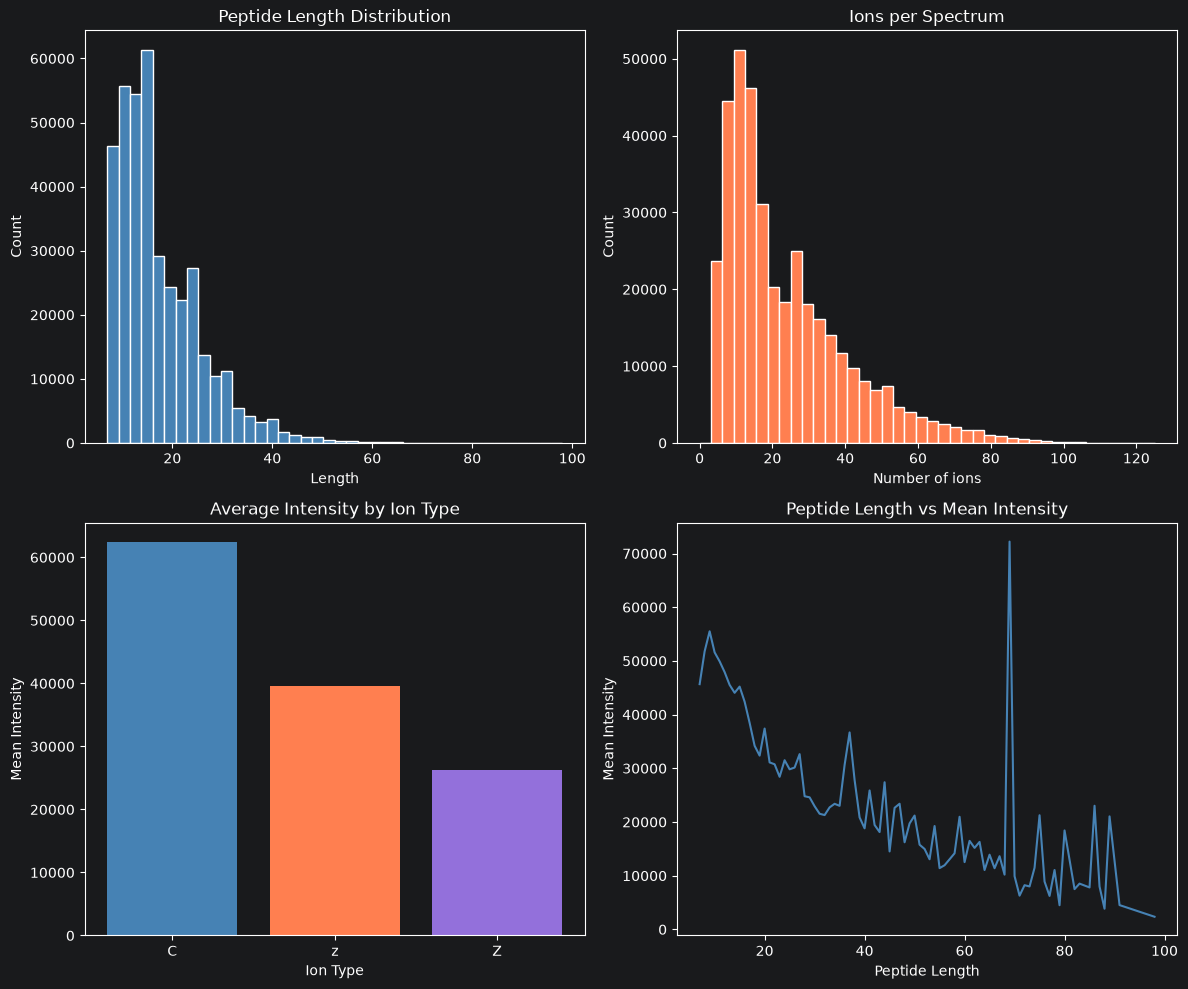

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(df['pep_length'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Peptide Length Distribution')
axes[0,0].set_xlabel('Length')
axes[0,0].set_ylabel('Count')

axes[0,1].hist(df['n_ions'], bins=40, color='coral', edgecolor='white')
axes[0,1].set_title('Ions per Spectrum')
axes[0,1].set_xlabel('Number of ions')
axes[0,1].set_ylabel('Count')

ion_intensities = {'C': [], 'z': [], 'Z': []}
for ions, intensities in zip(df['matched_ions'], df['intensity']):
    for ion, intensity in zip(ions, intensities):
        ion_type = ion[0]
        if ion_type in ion_intensities:
            ion_intensities[ion_type].append(intensity)

means = {k: np.mean(v) for k, v in ion_intensities.items()}
axes[1,0].bar(means.keys(), means.values(), color=['steelblue', 'coral', 'mediumpurple'])
axes[1,0].set_title('Average Intensity by Ion Type')
axes[1,0].set_xlabel('Ion Type')
axes[1,0].set_ylabel('Mean Intensity')

length_groups = df.groupby('pep_length')['mean_intensity'].mean()
axes[1,1].plot(length_groups.index, length_groups.values, color='steelblue')
axes[1,1].set_title('Peptide Length vs Mean Intensity')
axes[1,1].set_xlabel('Peptide Length')
axes[1,1].set_ylabel('Mean Intensity')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150)
plt.show()

In [7]:
df = pd.read_parquet("data_for_student.parquet").reset_index(drop=True)

def find_enzyme(filename):
    if 'LysC' in filename:  return 'LysC'
    if 'chymo' in filename: return 'Chymotrypsin'
    if 'LysN' in filename:  return 'LysN'
    if 'tryps' in filename: return 'Trypsin'
    if 'GluC' in filename:  return 'GluC'
    return 'Anderes'

df['enzyme'] = df['raw_file'].apply(find_enzyme)

df['bin'] = pd.qcut(df.index, q=20, labels=False)

percentage_table = pd.crosstab(df['bin'], df['enzyme'], normalize='index') * 100

plt.figure(figsize=(12, 6))


enzymes_to_plot = ['LysC', 'Chymotrypsin', 'LysN', 'Trypsin', 'GluC', 'Anderes']

for enzyme in enzymes_to_plot:
    if enzyme in percentage_table.columns:
        x_values = percentage_table.index
        y_values = percentage_table[enzyme]

        plt.plot(x_values, y_values, label=enzyme)


plt.title('Enzymaufteilung')
plt.xlabel('Position in Dataset (5% bins)')
plt.ylabel('Anteil')
plt.legend(loc='upper right')
plt.savefig('Enzymaufteilung.png')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data_for_student.parquet'

In [ ]:
# Expand: one row per ion
rows = []
for _, row in df.iterrows():
    seq = row['modified_sequence']
    for ion, intensity in zip(row['matched_ions'], row['intensity']):
        rows.append({
            'sequence': seq,
            'ion': ion,
            'intensity': intensity
        })

ion_df = pd.DataFrame(rows)
print(ion_df.shape)
print(ion_df.head(10))

In [ ]:
import re

def parse_ion(ion_str):
    # Ion type: first character
    ion_type = ion_str[0]
    
    # Charge: after ^ if present, else 1
    if '^' in ion_str:
        charge = int(ion_str.split('^')[1])
        number_str = re.search(r'[0-9]+', ion_str.split('^')[0]).group()
    else:
        charge = 1
        number_str = re.search(r'[0-9]+', ion_str).group()
    
    fragment_number = int(number_str)
    return ion_type, fragment_number, charge

print(parse_ion('C4'))
print(parse_ion('z9^2'))
print(parse_ion('Z11^2'))

In [ ]:
# Viel schneller: pandas string operations statt apply
ion_df['ion_charge'] = ion_df['ion'].str.extract(r'\^(\d+)').fillna(1).astype(int)
ion_df['ion_type'] = ion_df['ion'].str[0]
ion_df['fragment_number'] = ion_df['ion'].str.extract(r'[A-Za-z]+(\d+)').astype(int)

print(ion_df.head(10))

In [ ]:
# Label encoding für ion_type
ion_type_map = {'C': 0, 'z': 1, 'Z': 2}
ion_df['ion_type_encoded'] = ion_df['ion_type'].map(ion_type_map)

print(ion_df['ion_type_encoded'].value_counts())
print(ion_df.head(5))

In [ ]:
# Peptidlänge und relative Position
ion_df['pep_length'] = ion_df['sequence'].str.len()
ion_df['relative_position'] = ion_df['fragment_number'] / ion_df['pep_length']

print(ion_df.columns.tolist())
print(ion_df.head(3))

In [ ]:
print("=== EDA Summary ===")
print(f"Total ions: {len(ion_df):,}")
print(f"Unique peptides: {ion_df['sequence'].nunique():,}")
print(f"Ion types: {ion_df['ion_type'].value_counts().to_dict()}")
print(f"Peptide length range: {ion_df['pep_length'].min()} - {ion_df['pep_length'].max()}")
print(f"Fragment number range: {ion_df['fragment_number'].min()} - {ion_df['fragment_number'].max()}")
print(f"Charge states: {sorted(ion_df['ion_charge'].unique())}")
print(f"Intensity range: {ion_df['intensity'].min():.1f} - {ion_df['intensity'].max():.1f}")
print(f"Modified peptides: {ion_df['sequence'].str.contains('[', regex=False).sum():,}")